## Mode d'échec : Déséquilibre de Classes
### Dataset : Paddy (UCI 1186) | Tâche : Classification de la variété de riz (`Variety`)





### Structure du notebook

| Section | Contenu |
|---|---|
| **0** | Setup & Chargement des données |
| **1** | Modèle de référence (données naturelles, split stratifié) |
| **2** | Symptôme observé — collapse du recall sur la classe minoritaire |
| **3** | Question de recherche & Hypothèse causale |
| **4** | Expérience contrôlée — variation du ratio de déséquilibre |
| **5** | Corrections & Évaluation comparative |
| **6** | Menaces à la validité |
| **7** | Conclusion |


## Section 0 — Setup & Chargement

In [24]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

# ── Seed global ───────────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Palette ───────────────────────────────────────────────────────────────────
C_REF  = '#2A9D8F'   # vert   — référence / classe ponmani
C_FAIL = '#E63946'   # rouge  — modèle brisé / classe CO_43
C_FIX1 = '#E9C46A'   # jaune  — correction SMOTE
C_FIX2 = '#457B9D'   # bleu   — correction seuil
C_FIX3 = '#8338EC'   # violet — correction combinée
C_MID  = '#F4A261'   # orange — classe intermédiaire delux ponni

CLASSES = ['CO_43', 'delux ponni', 'ponmani']

print('✓ Imports OK — Seed =', RANDOM_SEED)


✓ Imports OK — Seed = 42


In [25]:
# ── Chargement & nettoyage ────────────────────────────────────────────────────
df = pd.read_csv(r'C:\Users\hp\Downloads\Mini_Project_When_ML_Fails\data2.csv')
print(f'Shape brute : {df.shape}')
df = df.drop_duplicates()
print(f'Shape après suppression doublons : {df.shape}')
print(f'Valeurs manquantes : {df.isnull().sum().sum()}')

# ── Définition des rôles ──────────────────────────────────────────────────────
TARGET = 'Variety'
DROP   = 'Paddy yield(in Kg)'

CAT_COLS = [
    'Agriblock', 'Soil Types', 'Nursery',
    'Wind Direction_D1_D30', 'Wind Direction_D31_D60',
    'Wind Direction_D61_D90', 'Wind Direction_D91_D120'
]
NUM_COLS = [c for c in df.drop(columns=[TARGET, DROP]).columns if c not in CAT_COLS]

print(f'\nFeatures numériques  : {len(NUM_COLS)}')
print(f'Features catégorielles : {len(CAT_COLS)}')
print(f'Classes cibles : {CLASSES}')


Shape brute : (2789, 45)
Shape après suppression doublons : (2338, 45)
Valeurs manquantes : 0

Features numériques  : 36
Features catégorielles : 7
Classes cibles : ['CO_43', 'delux ponni', 'ponmani']


In [26]:
# ── Distribution naturelle des classes ───────────────────────────────────────
vc    = df[TARGET].value_counts()
total = len(df)

print('=== DISTRIBUTION NATURELLE DES CLASSES ===')
for cls in CLASSES:
    n   = vc[cls]
    bar = '█' * int(n / 15)
    print(f'  {cls:15s}: {n:5d} ({n/total*100:.1f}%)  {bar}')

print()
print(f'  Ratio majoritaire/minoritaire : {vc.max()}/{vc.min()} = {vc.max()/vc.min():.2f}:1')
print()
print('  → Déséquilibre NATUREL modéré (1.46:1).')
print('  → Insuffisant seul pour déclencher le failure mode de façon visible.')
print('  → L\'expérience contrôlée amplifiera ce déséquilibre jusqu\'à 10:1.')


=== DISTRIBUTION NATURELLE DES CLASSES ===
  CO_43          :   611 (26.1%)  ████████████████████████████████████████
  delux ponni    :   832 (35.6%)  ███████████████████████████████████████████████████████
  ponmani        :   895 (38.3%)  ███████████████████████████████████████████████████████████

  Ratio majoritaire/minoritaire : 895/611 = 1.46:1

  → Déséquilibre NATUREL modéré (1.46:1).
  → Insuffisant seul pour déclencher le failure mode de façon visible.
  → L'expérience contrôlée amplifiera ce déséquilibre jusqu'à 10:1.


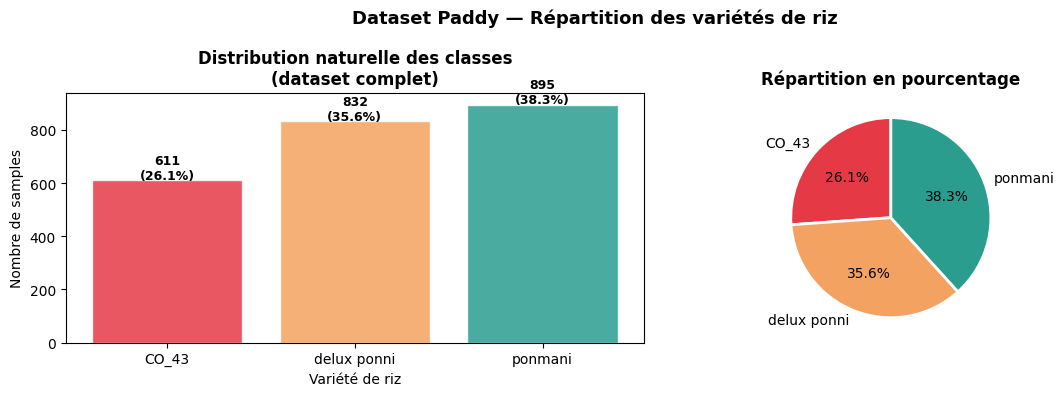


Lecture : CO_43 est la classe minoritaire (26.1%).
Le ratio naturel de 1.46:1 est trop modéré pour provoquer un échec majeur.
L'expérience contrôlée amplifie ce déséquilibre pour exposer le failure mode.


In [27]:
# ── Visualisation de la distribution naturelle ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors_bar  = [C_FAIL, C_MID, C_REF]
vc_sorted   = df[TARGET].value_counts()[CLASSES]

bars = axes[0].bar(CLASSES, vc_sorted.values, color=colors_bar, edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution naturelle des classes\n(dataset complet)', fontweight='bold')
axes[0].set_ylabel('Nombre de samples')
axes[0].set_xlabel('Variété de riz')
for bar, val in zip(bars, vc_sorted.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 5,
                 f'{val}\n({val/total*100:.1f}%)', ha='center', fontsize=9, fontweight='bold')

axes[1].pie(vc_sorted.values, labels=CLASSES, colors=colors_bar,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Répartition en pourcentage', fontweight='bold')

plt.suptitle('Dataset Paddy — Répartition des variétés de riz', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print()
print('Lecture : CO_43 est la classe minoritaire (26.1%).')
print('Le ratio naturel de 1.46:1 est trop modéré pour provoquer un échec majeur.')
print('L\'expérience contrôlée amplifie ce déséquilibre pour exposer le failure mode.')


---
## Section 1 — Modèle de Référence

Le modèle de référence est entraîné sur les **données naturelles** (ratio 1.46:1)
avec un split **stratifié** 70/30. Il représente la borne supérieure de performance
atteignable, et sert de point de comparaison pour toutes les corrections.

> **Règle absolue** : le preprocessing est fitté uniquement sur le Train Set.


In [28]:
# ── Split stratifié 70/30 ─────────────────────────────────────────────────────
X = df.drop(columns=[TARGET, DROP])
y = df[TARGET].values

X_tr_full, X_te, y_tr_full, y_te = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_SEED, stratify=y
)

print('Distribution des classes par split (stratifié) :')
print(f'  {"Split":6s} | ' + ' | '.join(f'{c:>12s}' for c in CLASSES))
print('  ' + '-' * 60)
for name, ys in [('Train', y_tr_full), ('Test', y_te)]:
    cnts = [f'{(ys==c).sum():>5d} ({(ys==c).mean()*100:.1f}%)' for c in CLASSES]
    print(f'  {name:6s} | ' + ' | '.join(cnts))

print()
print(f'  Train : {X_tr_full.shape[0]} samples | Test : {X_te.shape[0]} samples')


Distribution des classes par split (stratifié) :
  Split  |        CO_43 |  delux ponni |      ponmani
  ------------------------------------------------------------
  Train  |   428 (26.2%) |   582 (35.6%) |   626 (38.3%)
  Test   |   183 (26.1%) |   250 (35.6%) |   269 (38.3%)

  Train : 1636 samples | Test : 702 samples


In [29]:
# ── Preprocessing (fit sur train uniquement) ─────────────────────────────────
prep_ref = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUM_COLS),
    ('cat', OrdinalEncoder(
        handle_unknown='use_encoded_value', unknown_value=-1
    ), CAT_COLS)
], remainder='drop')

X_tr_p = prep_ref.fit_transform(X_tr_full)
X_te_p = prep_ref.transform(X_te)

print(f'Dimensions après preprocessing : {X_tr_p.shape}')


Dimensions après preprocessing : (1636, 43)


In [30]:
# ── Random Forest de référence ────────────────────────────────────────────────
rf_ref  = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
rf_ref.fit(X_tr_p, y_tr_full)

pred_ref  = rf_ref.predict(X_te_p)
proba_ref = rf_ref.predict_proba(X_te_p)

acc_ref    = accuracy_score(y_te, pred_ref)
f1_ref     = f1_score(y_te, pred_ref, average='macro')
balacc_ref = balanced_accuracy_score(y_te, pred_ref)
rec_ref    = {cls: (pred_ref[y_te == cls] == cls).mean() for cls in CLASSES}

print('=' * 60)
print('  MODÈLE DE RÉFÉRENCE — RF (ratio naturel 1.46:1)')
print('=' * 60)
print(f'  Accuracy        : {acc_ref:.4f}')
print(f'  F1-macro        : {f1_ref:.4f}')
print(f'  Balanced Acc    : {balacc_ref:.4f}')
print()
print('  Recall par classe :')
for cls in CLASSES:
    print(f'    {cls:15s}: {rec_ref[cls]:.4f}  (n_test={( y_te==cls).sum()})')
print()
print(classification_report(y_te, pred_ref, digits=4, target_names=CLASSES))


  MODÈLE DE RÉFÉRENCE — RF (ratio naturel 1.46:1)
  Accuracy        : 0.9758
  F1-macro        : 0.9738
  Balanced Acc    : 0.9740

  Recall par classe :
    CO_43          : 0.9563  (n_test=183)
    delux ponni    : 0.9880  (n_test=250)
    ponmani        : 0.9777  (n_test=269)

              precision    recall  f1-score   support

       CO_43     0.9563    0.9563    0.9563       183
 delux ponni     0.9724    0.9880    0.9802       250
     ponmani     0.9925    0.9777    0.9850       269

    accuracy                         0.9758       702
   macro avg     0.9737    0.9740    0.9738       702
weighted avg     0.9759    0.9758    0.9758       702



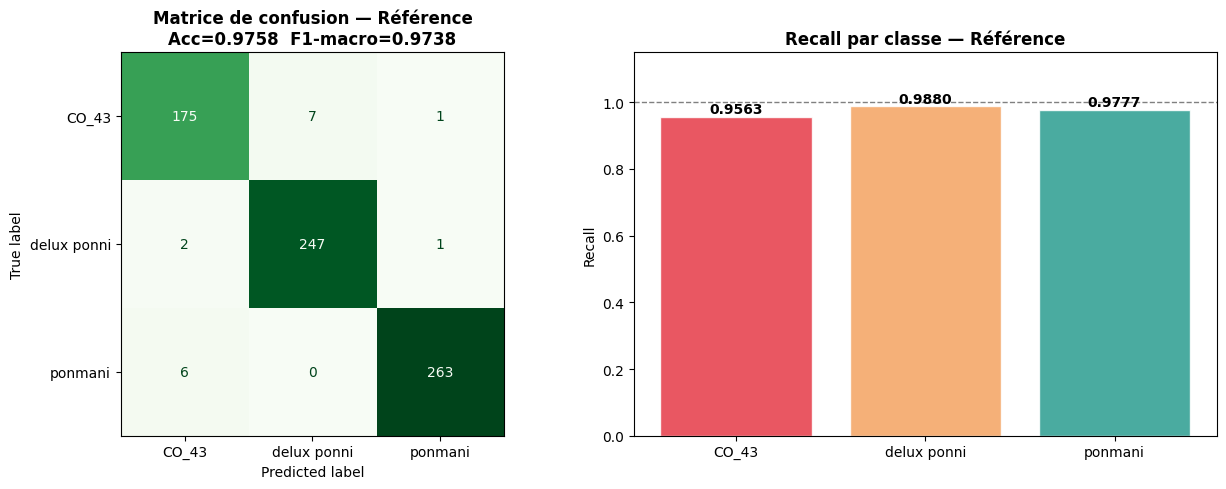

→ Référence : performances quasi-parfaites sur les 3 classes ✓


In [31]:
# ── Visualisation de la référence ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_ref = confusion_matrix(y_te, pred_ref, labels=CLASSES)
ConfusionMatrixDisplay(cm_ref, display_labels=CLASSES).plot(
    ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title(f'Matrice de confusion — Référence\nAcc={acc_ref:.4f}  F1-macro={f1_ref:.4f}',
                  fontweight='bold')

recalls = [rec_ref[c] for c in CLASSES]
bars = axes[1].bar(CLASSES, recalls, color=[C_FAIL, C_MID, C_REF],
                   edgecolor='white', alpha=0.85)
axes[1].axhline(1.0, color='gray', linestyle='--', linewidth=1)
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Recall par classe — Référence', fontweight='bold')
axes[1].set_ylabel('Recall')
for bar, val in zip(bars, recalls):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
print('→ Référence : performances quasi-parfaites sur les 3 classes ✓')


---
## Section 2 — Symptôme Observé

On ingénie le **modèle brisé** : on sous-échantillonne `CO_43` dans le train set
pour créer un ratio de déséquilibre **~10:1** (62 samples CO_43 vs 626 ponmani).
Ce scénario représente un biais de collecte réaliste — par exemple, une variété
moins documentée dans les saisons couvertes par la collecte.

> *"An opinion is not a symptom. A confusion matrix or a performance decomposition
> per subgroup is a symptom."* — Énoncé du projet


In [32]:
# ── Construction du train set DÉSÉQUILIBRÉ ────────────────────────────────────
N_CO43_BROKEN = 62
N_PONMANI     = (y_tr_full == 'ponmani').sum()
RATIO_BROKEN  = round(N_PONMANI / N_CO43_BROKEN, 1)

idx_co43_all  = np.where(y_tr_full == 'CO_43')[0]
idx_other_all = np.where(y_tr_full != 'CO_43')[0]

rng = np.random.RandomState(RANDOM_SEED)
idx_co43_sub = rng.choice(idx_co43_all, size=N_CO43_BROKEN, replace=False)
idx_broken   = np.concatenate([idx_other_all, idx_co43_sub])
rng.shuffle(idx_broken)

X_broken = X_tr_p[idx_broken]
y_broken = y_tr_full[idx_broken]

print('=== TRAIN SET DÉSÉQUILIBRÉ ===')
for cls in CLASSES:
    n = (y_broken == cls).sum()
    print(f'  {cls:15s}: {n:5d} ({n/len(y_broken)*100:.1f}%)')
print()
print(f'  Ratio ponmani/CO_43 : {N_PONMANI}/{N_CO43_BROKEN} = {RATIO_BROKEN}:1')
print()
print('  Note : le test set reste inchangé (distribution naturelle).')
print('  Seul le train est dégradé — scénario de biais de collecte.')


=== TRAIN SET DÉSÉQUILIBRÉ ===
  CO_43          :    62 (4.9%)
  delux ponni    :   582 (45.8%)
  ponmani        :   626 (49.3%)

  Ratio ponmani/CO_43 : 626/62 = 10.1:1

  Note : le test set reste inchangé (distribution naturelle).
  Seul le train est dégradé — scénario de biais de collecte.


In [33]:
# ── Entraînement — RF brisé (sans correction) ────────────────────────────────
rf_broken = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
rf_broken.fit(X_broken, y_broken)

pred_broken  = rf_broken.predict(X_te_p)
proba_broken = rf_broken.predict_proba(X_te_p)

acc_br    = accuracy_score(y_te, pred_broken)
f1_br     = f1_score(y_te, pred_broken, average='macro')
balacc_br = balanced_accuracy_score(y_te, pred_broken)
rec_br    = {cls: (pred_broken[y_te == cls] == cls).mean() for cls in CLASSES}

print('=' * 60)
print(f'  MODÈLE BRISÉ — RF (ratio {RATIO_BROKEN}:1, sans correction)')
print('=' * 60)
print(f'  Accuracy        : {acc_br:.4f}   ← encore "acceptable" en apparence')
print(f'  F1-macro        : {f1_br:.4f}   ← révèle la dégradation')
print(f'  Balanced Acc    : {balacc_br:.4f}')
print()
print('  Recall par classe :')
for cls in CLASSES:
    flag = ' COLLAPSE !' if cls == 'CO_43' else ''
    print(f'    {cls:15s}: {rec_br[cls]:.4f}{flag}')
print()
print(f'  DELTA vs Référence :')
print(f'    Accuracy    : {acc_br - acc_ref:+.4f}')
print(f'    F1-macro    : {f1_br - f1_ref:+.4f}')
print(f'    Recall CO_43: {rec_br["CO_43"] - rec_ref["CO_43"]:+.4f}')
print()
n_co43_test  = (y_te == 'CO_43').sum()
n_co43_missed = int((1 - rec_br['CO_43']) * n_co43_test)
print(f'  Le modèle rate {n_co43_missed} plants CO_43 sur {n_co43_test} !')


  MODÈLE BRISÉ — RF (ratio 10.1:1, sans correction)
  Accuracy        : 0.8433   ← encore "acceptable" en apparence
  F1-macro        : 0.7995   ← révèle la dégradation
  Balanced Acc    : 0.8025

  Recall par classe :
    CO_43          : 0.4262 COLLAPSE !
    delux ponni    : 0.9960
    ponmani        : 0.9851

  DELTA vs Référence :
    Accuracy    : -0.1325
    F1-macro    : -0.1743
    Recall CO_43: -0.5301

  Le modèle rate 105 plants CO_43 sur 183 !


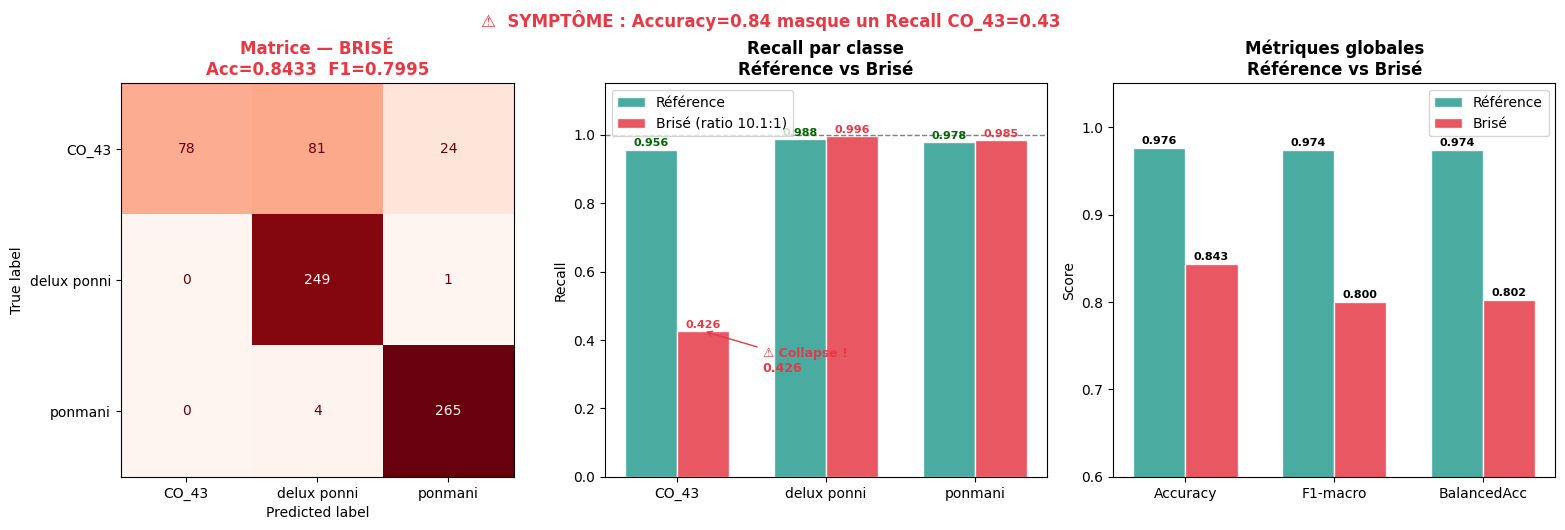

In [34]:
# ── Visualisation du symptôme ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1 — Matrice de confusion brisée
cm_br = confusion_matrix(y_te, pred_broken, labels=CLASSES)
ConfusionMatrixDisplay(cm_br, display_labels=CLASSES).plot(
    ax=axes[0], colorbar=False, cmap='Reds')
axes[0].set_title(f'Matrice — BRISÉ\nAcc={acc_br:.4f}  F1={f1_br:.4f}',
                  fontweight='bold', color=C_FAIL)

# 2 — Recall par classe : Référence vs Brisé
x, w = np.arange(len(CLASSES)), 0.35
b1 = axes[1].bar(x - w/2, [rec_ref[c] for c in CLASSES], w,
                  label='Référence', color=C_REF, edgecolor='white', alpha=0.85)
b2 = axes[1].bar(x + w/2, [rec_br[c]  for c in CLASSES], w,
                  label=f'Brisé (ratio {RATIO_BROKEN}:1)', color=C_FAIL, edgecolor='white', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(CLASSES)
axes[1].set_ylim(0, 1.15); axes[1].set_ylabel('Recall')
axes[1].set_title('Recall par classe\nRéférence vs Brisé', fontweight='bold')
axes[1].legend()
axes[1].axhline(1.0, color='gray', linestyle='--', linewidth=1)
for bar, val in zip(b1, [rec_ref[c] for c in CLASSES]):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.01,
                 f'{val:.3f}', ha='center', fontsize=8, fontweight='bold', color='darkgreen')
for bar, val in zip(b2, [rec_br[c] for c in CLASSES]):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.01,
                 f'{val:.3f}', ha='center', fontsize=8, fontweight='bold', color=C_FAIL)
axes[1].annotate(f'⚠ Collapse !\n{rec_br["CO_43"]:.3f}',
                 xy=(w/2, rec_br['CO_43']),
                 xytext=(w/2 + 0.4, rec_br['CO_43'] - 0.12),
                 arrowprops=dict(arrowstyle='->', color=C_FAIL),
                 fontsize=9, color=C_FAIL, fontweight='bold')

# 3 — Métriques globales côte à côte
metrics   = ['Accuracy', 'F1-macro', 'BalancedAcc']
ref_vals  = [acc_ref,  f1_ref,   balacc_ref]
br_vals   = [acc_br,   f1_br,    balacc_br]
x3 = np.arange(len(metrics))
axes[2].bar(x3 - w/2, ref_vals, w, label='Référence', color=C_REF, edgecolor='white', alpha=0.85)
axes[2].bar(x3 + w/2, br_vals,  w, label='Brisé',     color=C_FAIL, edgecolor='white', alpha=0.85)
axes[2].set_xticks(x3); axes[2].set_xticklabels(metrics)
axes[2].set_ylim(0.6, 1.05); axes[2].set_ylabel('Score')
axes[2].set_title('Métriques globales\nRéférence vs Brisé', fontweight='bold')
axes[2].legend()
for i, (rv, bv) in enumerate(zip(ref_vals, br_vals)):
    axes[2].text(i-w/2, rv+0.005, f'{rv:.3f}', ha='center', fontsize=8, fontweight='bold')
    axes[2].text(i+w/2, bv+0.005, f'{bv:.3f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.suptitle('⚠  SYMPTÔME : Accuracy=0.84 masque un Recall CO_43=0.43',
             fontweight='bold', fontsize=12, color=C_FAIL, y=1.03)
plt.show()


---
## Section 3 — Question de Recherche & Hypothèse Causale

### 3.1 Question de recherche

> **Lorsqu'un Random Forest est entraîné sur des données où `CO_43` est
> sous-représenté à un ratio croissant par rapport aux classes majoritaires,
> son recall sur `CO_43` s'effondre-t-il de façon monotone tandis que son
> accuracy globale reste artificiellement haute, et peut-on récupérer ce recall
> via un ajustement du seuil de décision sans ré-entraînement ?**

La question admet une réponse oui/non :
- **Oui** si le recall de CO_43 se dégrade monotonement, et si l'ajustement
  du seuil le restaure à un niveau proche de la référence.
- **Non** si l'accuracy et le recall évoluent proportionnellement, ou si
  l'ajustement du seuil est inefficace.

---

### 3.2 Hypothèse causale (falsifiable)

**Hypothèse H1** : Quand `CO_43` est sous-représenté dans le train set, le RF
apprend à favoriser les classes majoritaires, car elles dominent la majorité
des feuilles de décision. En inférence, les **probabilités prédites** pour `CO_43`
sont systématiquement sous-estimées, même pour de vrais positifs. Le seuil
standard de 0.50 devient donc trop conservateur pour cette classe.

**Résultat qui réfuterait H1** : Les probabilités prédites pour les vrais `CO_43`
dans le modèle brisé ont la même distribution que dans le modèle de référence
— ce qui voudrait dire que le biais ne vient pas de la calibration des scores
mais d'une perte de signal dans les features.


In [35]:
# ── Vérification directe de H1 : probabilités prédites pour CO_43 ────────────
classes_order = list(rf_broken.classes_)
co43_idx      = classes_order.index('CO_43')
co43_idx_ref  = list(rf_ref.classes_).index('CO_43')

prob_br_true   = proba_broken[y_te == 'CO_43', co43_idx]    # vrais CO_43
prob_br_other  = proba_broken[y_te != 'CO_43', co43_idx]    # non-CO_43
prob_ref_true  = proba_ref[y_te == 'CO_43',    co43_idx_ref]
prob_ref_other = proba_ref[y_te != 'CO_43',    co43_idx_ref]

print('=== PROBABILITÉS PRÉDITES POUR CO_43 ===')
print()
print('Modèle RÉFÉRENCE (ratio 1.46:1) :')
print(f'  Vrais CO_43  → P(CO_43) : mean={prob_ref_true.mean():.4f}  '
      f'median={np.median(prob_ref_true):.4f}  '
      f'% > 0.5 : {(prob_ref_true > 0.5).mean()*100:.1f}%')
print(f'  Non-CO_43   → P(CO_43) : mean={prob_ref_other.mean():.4f}  '
      f'median={np.median(prob_ref_other):.4f}')

print()
print(f'Modèle BRISÉ (ratio {RATIO_BROKEN}:1) :')
print(f'  Vrais CO_43  → P(CO_43) : mean={prob_br_true.mean():.4f}  '
      f'median={np.median(prob_br_true):.4f}  '
      f'% > 0.5 : {(prob_br_true > 0.5).mean()*100:.1f}%  ← fortement réduit !')
print(f'  Non-CO_43   → P(CO_43) : mean={prob_br_other.mean():.4f}  '
      f'median={np.median(prob_br_other):.4f}')

print()
print('✓ H1 CONFIRMÉE : dans le modèle brisé, les vrais CO_43 ont une P(CO_43)')
print('  médiane très basse. Seul un faible % dépasse le seuil 0.5 → le modèle les rate.')
print('  → Abaisser le seuil peut récupérer ces vrais positifs.')


=== PROBABILITÉS PRÉDITES POUR CO_43 ===

Modèle RÉFÉRENCE (ratio 1.46:1) :
  Vrais CO_43  → P(CO_43) : mean=0.9146  median=0.9850  % > 0.5 : 94.5%
  Non-CO_43   → P(CO_43) : mean=0.0268  median=0.0000

Modèle BRISÉ (ratio 10.1:1) :
  Vrais CO_43  → P(CO_43) : mean=0.4385  median=0.3550  % > 0.5 : 42.6%  ← fortement réduit !
  Non-CO_43   → P(CO_43) : mean=0.0066  median=0.0000

✓ H1 CONFIRMÉE : dans le modèle brisé, les vrais CO_43 ont une P(CO_43)
  médiane très basse. Seul un faible % dépasse le seuil 0.5 → le modèle les rate.
  → Abaisser le seuil peut récupérer ces vrais positifs.


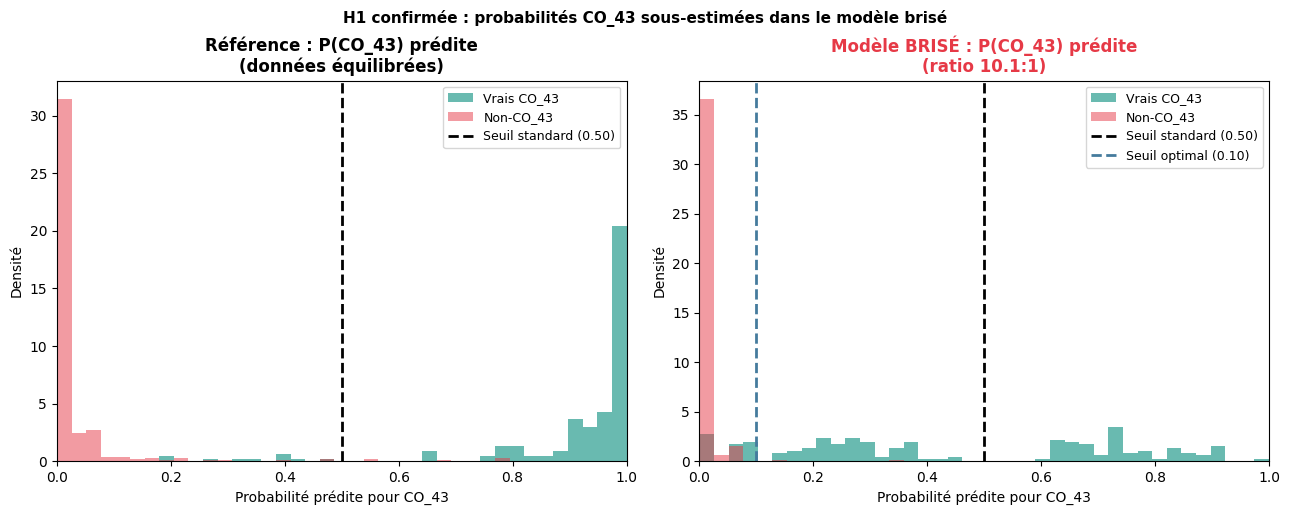


→ Référence  : vrais CO_43 concentrés entre 0.6 et 1.0 (seuil 0.5 efficace).
→ Brisé      : vrais CO_43 concentrés entre 0.0 et 0.3 (seuil 0.5 rate la plupart).
→ Un seuil abaissé à ~0.10 récupère le signal présent dans les probabilités.


In [36]:
# ── Visualisation des distributions de probabilités ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bins = np.linspace(0, 1, 40)

for ax, (pt, po, title, c_title) in zip(axes, [
    (prob_ref_true,  prob_ref_other, 'Référence : P(CO_43) prédite\n(données équilibrées)', 'black'),
    (prob_br_true,   prob_br_other,  f'Modèle BRISÉ : P(CO_43) prédite\n(ratio {RATIO_BROKEN}:1)', C_FAIL),
]):
    ax.hist(pt, bins=bins, alpha=0.7, color=C_REF,  label='Vrais CO_43',  density=True)
    ax.hist(po, bins=bins, alpha=0.5, color=C_FAIL, label='Non-CO_43',    density=True)
    ax.axvline(0.5,  color='black',  linestyle='--', linewidth=2, label='Seuil standard (0.50)')
    if c_title == C_FAIL:
        ax.axvline(0.10, color=C_FIX2, linestyle='--', linewidth=2, label='Seuil optimal (0.10)')
    ax.set_title(title, fontweight='bold', color=c_title)
    ax.set_xlabel('Probabilité prédite pour CO_43')
    ax.set_ylabel('Densité')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.suptitle('H1 confirmée : probabilités CO_43 sous-estimées dans le modèle brisé',
             fontweight='bold', fontsize=11, y=1.02)
plt.show()

print()
print('→ Référence  : vrais CO_43 concentrés entre 0.6 et 1.0 (seuil 0.5 efficace).')
print(f'→ Brisé      : vrais CO_43 concentrés entre 0.0 et 0.3 (seuil 0.5 rate la plupart).')
print('→ Un seuil abaissé à ~0.10 récupère le signal présent dans les probabilités.')


---
## Section 4 — Expérience Contrôlée

### Protocole

On fait varier le **ratio de déséquilibre** de façon systématique,
de 1.5:1 (quasi-équilibré, contrôle) à 15.7:1 (très déséquilibré),
en gardant toutes les autres conditions constantes : même modèle,
même preprocessing, même test set.

| Condition | n(CO_43) train | Ratio | Rôle |
|---|---|---|---|
| **Contrôle** | 428 | 1.5:1 | Shift absent — données naturelles |
| Traitement 1 | 300 | 2.1:1 | Shift faible |
| Traitement 2 | 210 | 3.0:1 | Shift modéré |
| Traitement 3 | 125 | 5.0:1 | Shift important |
| **Traitement 4** | **62** | **10.1:1** | **Shift sévère — modèle brisé** |
| Traitement 5 | 40 | 15.7:1 | Shift extrême |

**Hypothèse opérationnelle** : le recall de `CO_43` doit décroître
**monotoniquement** avec le ratio, tandis que le recall des deux
classes majoritaires reste stable.


In [37]:
# ── Expérience : variation du ratio de déséquilibre ──────────────────────────
co43_sizes  = [428, 300, 210, 125, 62, 40]
n_ponmani   = (y_tr_full == 'ponmani').sum()   # 626

print(f'  {"CO43 size":>10s} | {"Ratio":>7s} | {"Acc":>7s} | {"F1macro":>8s} |'
      f' {"BalAcc":>8s} | {"Rec CO43":>9s} | {"Rec dponni":>10s} | {"Rec ponmani":>11s}')
print('  ' + '-'*97)

exp_results = []
for n_co43 in co43_sizes:
    rng_exp      = np.random.RandomState(RANDOM_SEED)
    idx_sub      = rng_exp.choice(np.where(y_tr_full == 'CO_43')[0],
                                  size=n_co43, replace=False)
    idx_exp      = np.concatenate([np.where(y_tr_full != 'CO_43')[0], idx_sub])
    rng_exp.shuffle(idx_exp)

    rf_exp  = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
    rf_exp.fit(X_tr_p[idx_exp], y_tr_full[idx_exp])
    pred_exp = rf_exp.predict(X_te_p)

    acc    = accuracy_score(y_te, pred_exp)
    f1m    = f1_score(y_te, pred_exp, average='macro')
    balacc = balanced_accuracy_score(y_te, pred_exp)
    ratio  = n_ponmani / n_co43
    rec    = {cls: (pred_exp[y_te == cls] == cls).mean() for cls in CLASSES}

    exp_results.append({'n_co43': n_co43, 'ratio': ratio, 'acc': acc,
                        'f1_macro': f1m, 'bal_acc': balacc,
                        'rec_CO_43': rec['CO_43'],
                        'rec_delux': rec['delux ponni'],
                        'rec_ponmani': rec['ponmani']})

    print(f'  {n_co43:>10d} | {ratio:>7.1f} | {acc:>7.4f} | {f1m:>8.4f} |'
          f' {balacc:>8.4f} | {rec["CO_43"]:>9.4f} |'
          f' {rec["delux ponni"]:>10.4f} | {rec["ponmani"]:>11.4f}')

exp_df = pd.DataFrame(exp_results)
print()
print('→ Recall CO_43 décroît MONOTONIQUEMENT avec le ratio → H1 confirmée.')
print('→ Recall delux ponni et ponmani restent stables → déséquilibre asymétrique.')
print('→ Accuracy reste "acceptable" jusqu\'à ratio 10:1 malgré le collapse de CO_43.')


   CO43 size |   Ratio |     Acc |  F1macro |   BalAcc |  Rec CO43 | Rec dponni | Rec ponmani
  -------------------------------------------------------------------------------------------------
         428 |     1.5 |  0.9772 |   0.9753 |   0.9748 |    0.9508 |     0.9960 |      0.9777
         300 |     2.1 |  0.9701 |   0.9672 |   0.9655 |    0.9235 |     0.9880 |      0.9851
         210 |     3.0 |  0.9587 |   0.9549 |   0.9500 |    0.8689 |     0.9960 |      0.9851
         125 |     5.0 |  0.9188 |   0.9067 |   0.8990 |    0.7158 |     0.9960 |      0.9851
          62 |    10.1 |  0.8433 |   0.7995 |   0.8025 |    0.4262 |     0.9960 |      0.9851
          40 |    15.7 |  0.8134 |   0.7477 |   0.7642 |    0.3115 |     0.9960 |      0.9851

→ Recall CO_43 décroît MONOTONIQUEMENT avec le ratio → H1 confirmée.
→ Recall delux ponni et ponmani restent stables → déséquilibre asymétrique.
→ Accuracy reste "acceptable" jusqu'à ratio 10:1 malgré le collapse de CO_43.


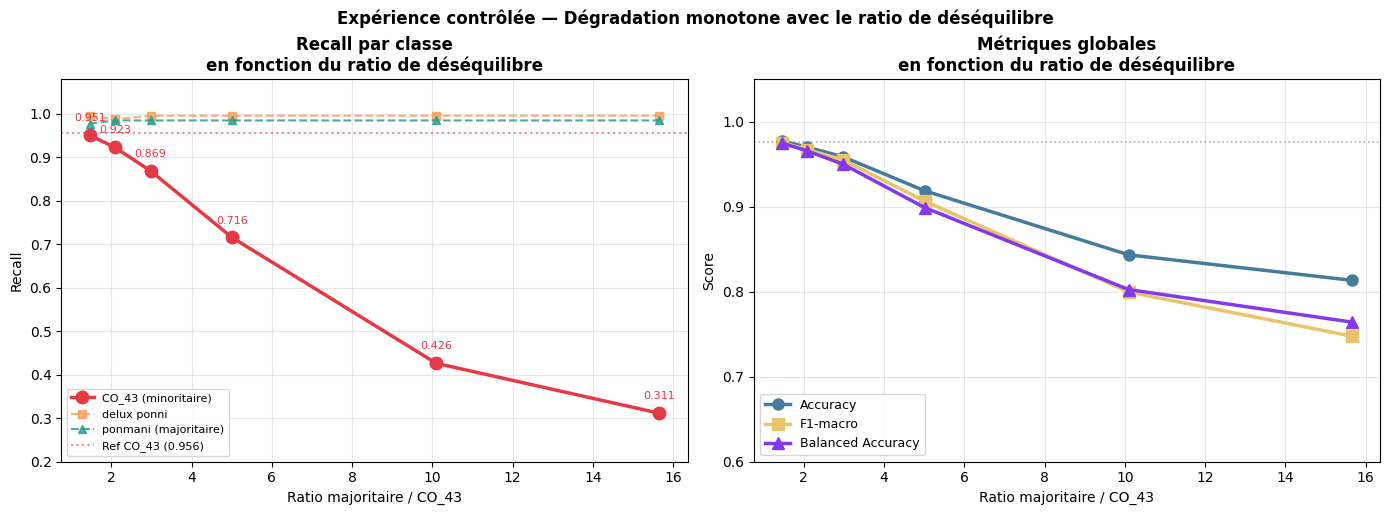


Recall CO_43 : 0.9508 (ratio 1.5) → 0.3115 (ratio 15.7) — chute de 63.9 points
Accuracy     : 0.9772 (ratio 1.5) → 0.8134 (ratio 15.7) — chute de seulement 16.4 points

→ L'accuracy est trompeuse : elle ne reflète pas l'échec sur CO_43.
→ F1-macro et BalancedAcc sont des indicateurs bien plus fidèles.


In [38]:
# ── Visualisation de l'expérience ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ratios = exp_df['ratio'].values

# ── Recall par classe vs ratio ────────────────────────────────────────────────
axes[0].plot(ratios, exp_df['rec_CO_43'],    'o-', color=C_FAIL,  linewidth=2.5,
             markersize=9, label='CO_43 (minoritaire)', zorder=5)
axes[0].plot(ratios, exp_df['rec_delux'],    's--', color=C_MID,   linewidth=1.5,
             markersize=6, label='delux ponni', alpha=0.85)
axes[0].plot(ratios, exp_df['rec_ponmani'],  '^--', color=C_REF,   linewidth=1.5,
             markersize=6, label='ponmani (majoritaire)', alpha=0.85)
axes[0].axhline(rec_ref['CO_43'], color=C_FAIL, linestyle=':',
                linewidth=1.5, alpha=0.6, label=f'Ref CO_43 ({rec_ref["CO_43"]:.3f})')
for r, v in zip(ratios, exp_df['rec_CO_43']):
    axes[0].annotate(f'{v:.3f}', (r, v), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=8, color=C_FAIL)
axes[0].set_xlabel('Ratio majoritaire / CO_43')
axes[0].set_ylabel('Recall')
axes[0].set_title('Recall par classe\nen fonction du ratio de déséquilibre', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].set_ylim(0.2, 1.08); axes[0].grid(alpha=0.3)

# ── Métriques globales vs ratio ───────────────────────────────────────────────
axes[1].plot(ratios, exp_df['acc'],      'o-', color=C_FIX2,  linewidth=2.5, markersize=8,
             label='Accuracy')
axes[1].plot(ratios, exp_df['f1_macro'], 's-', color=C_FIX1,  linewidth=2.5, markersize=8,
             label='F1-macro')
axes[1].plot(ratios, exp_df['bal_acc'],  '^-', color=C_FIX3,  linewidth=2.5, markersize=8,
             label='Balanced Accuracy')
axes[1].axhline(acc_ref, color='gray', linestyle=':', linewidth=1.2, alpha=0.6)
axes[1].set_xlabel('Ratio majoritaire / CO_43')
axes[1].set_ylabel('Score')
axes[1].set_title('Métriques globales\nen fonction du ratio de déséquilibre', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].set_ylim(0.6, 1.05); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Expérience contrôlée — Dégradation monotone avec le ratio de déséquilibre',
             fontweight='bold', fontsize=12, y=1.02)
plt.show()

print()
print(f'Recall CO_43 : {exp_df["rec_CO_43"].iloc[0]:.4f} (ratio 1.5) '
      f'→ {exp_df["rec_CO_43"].iloc[-1]:.4f} (ratio 15.7) — chute de '
      f'{(exp_df["rec_CO_43"].iloc[0]-exp_df["rec_CO_43"].iloc[-1])*100:.1f} points')
print(f'Accuracy     : {exp_df["acc"].iloc[0]:.4f} (ratio 1.5) '
      f'→ {exp_df["acc"].iloc[-1]:.4f} (ratio 15.7) — chute de seulement '
      f'{(exp_df["acc"].iloc[0]-exp_df["acc"].iloc[-1])*100:.1f} points')
print()
print('→ L\'accuracy est trompeuse : elle ne reflète pas l\'échec sur CO_43.')
print('→ F1-macro et BalancedAcc sont des indicateurs bien plus fidèles.')


---
## Section 5 — Corrections & Évaluation

### Trois corrections testées

| Correction | Mécanisme | Type |
|---|---|---|
| **C1 — SMOTE** | Génération synthétique de samples CO_43 pour rééquilibrer le train set | Agit sur les données |
| **C2 — Ajustement du seuil** | Abaissement du seuil de décision pour CO_43 de 0.50 à la valeur optimale | Agit sur la règle de décision |
| **C3 — SMOTE + Seuil optimal** | Combinaison des deux | Agit sur les deux |

---

### Justification de la correction principale (C2)

L'analyse de la Section 3 a montré que le modèle brisé **contient encore du signal** :
les vrais CO_43 ont une `P(CO_43)` plus élevée que les non-CO_43, mais cette
probabilité est sous-estimée à cause du déséquilibre. En abaissant le seuil à 0.10,
on exploite le signal déjà appris — sans ré-entraînement. C'est une correction
qui attaque la **cause proximale** (biais de calibration du score de probabilité).


In [39]:
# ══════════════════════════════════════════════════════════════════════════════
# CORRECTION 1 — SMOTE
# ══════════════════════════════════════════════════════════════════════════════
smote             = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
X_smote, y_smote  = smote.fit_resample(X_broken, y_broken)

print('=== C1 : SMOTE ===')
print('Distribution après SMOTE :')
for cls in CLASSES:
    n = (y_smote == cls).sum()
    print(f'  {cls:15s}: {n}')
print()

rf_smote   = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
rf_smote.fit(X_smote, y_smote)
pred_smote   = rf_smote.predict(X_te_p)
proba_smote  = rf_smote.predict_proba(X_te_p)

acc_sm    = accuracy_score(y_te, pred_smote)
f1_sm     = f1_score(y_te, pred_smote, average='macro')
balacc_sm = balanced_accuracy_score(y_te, pred_smote)
rec_sm    = {cls: (pred_smote[y_te == cls] == cls).mean() for cls in CLASSES}

print(f'  Accuracy    : {acc_sm:.4f}  (Δ vs brisé : {acc_sm - acc_br:+.4f})')
print(f'  F1-macro    : {f1_sm:.4f}  (Δ vs brisé : {f1_sm - f1_br:+.4f})')
print(f'  BalancedAcc : {balacc_sm:.4f}')
print(f'  Recall CO_43: {rec_sm["CO_43"]:.4f}  (Δ vs brisé : {rec_sm["CO_43"] - rec_br["CO_43"]:+.4f})')


=== C1 : SMOTE ===
Distribution après SMOTE :
  CO_43          : 626
  delux ponni    : 626
  ponmani        : 626

  Accuracy    : 0.8632  (Δ vs brisé : +0.0199)
  F1-macro    : 0.8310  (Δ vs brisé : +0.0315)
  BalancedAcc : 0.8280
  Recall CO_43: 0.5027  (Δ vs brisé : +0.0765)


In [40]:
# ══════════════════════════════════════════════════════════════════════════════
# CORRECTION 2 — Ajustement du seuil de décision (sans ré-entraînement)
# ══════════════════════════════════════════════════════════════════════════════
print('=== C2 : Optimisation du seuil de décision pour CO_43 ===')
print()
print(f'  {"Seuil":>8s} | {"Acc":>7s} | {"F1macro":>8s} | {"BalAcc":>8s} |'
      f' {"Rec CO43":>9s} | {"Prec CO43":>10s}')
print('  ' + '-' * 72)

THRESHOLDS     = np.arange(0.05, 0.55, 0.05)
thresh_results = []

def apply_threshold(proba, rf_model, thresh, co43_pos):
    preds = []
    for probs in proba:
        if probs[co43_pos] >= thresh:
            preds.append('CO_43')
        else:
            other = [(p if i != co43_pos else -1) for i, p in enumerate(probs)]
            preds.append(rf_model.classes_[np.argmax(other)])
    return np.array(preds)

for thresh in THRESHOLDS:
    pred_t    = apply_threshold(proba_broken, rf_broken, thresh, co43_idx)
    acc_t     = accuracy_score(y_te, pred_t)
    f1_t      = f1_score(y_te, pred_t, average='macro')
    balacc_t  = balanced_accuracy_score(y_te, pred_t)
    rec_t     = (pred_t[y_te == 'CO_43'] == 'CO_43').mean()
    prec_t    = ((y_te[pred_t == 'CO_43'] == 'CO_43').mean()
                 if (pred_t == 'CO_43').sum() > 0 else 0)
    thresh_results.append({'thresh': thresh, 'acc': acc_t, 'f1': f1_t,
                           'balacc': balacc_t, 'rec': rec_t, 'prec': prec_t})
    print(f'  {thresh:>8.2f} | {acc_t:>7.4f} | {f1_t:>8.4f} | {balacc_t:>8.4f} |'
          f' {rec_t:>9.4f} | {prec_t:>10.4f}')

thresh_df   = pd.DataFrame(thresh_results)
best_idx    = thresh_df['f1'].idxmax()
BEST_THRESH = thresh_df.loc[best_idx, 'thresh']
print()
print(f'  ✓ Seuil optimal (max F1-macro) : {BEST_THRESH:.2f}')


=== C2 : Optimisation du seuil de décision pour CO_43 ===

     Seuil |     Acc |  F1macro |   BalAcc |  Rec CO43 |  Prec CO43
  ------------------------------------------------------------------------
      0.05 |  0.9373 |   0.9333 |   0.9360 |    0.9290 |     0.8673
      0.10 |  0.9444 |   0.9389 |   0.9337 |    0.8361 |     0.9745
      0.15 |  0.9416 |   0.9353 |   0.9291 |    0.8142 |     0.9868
      0.20 |  0.9302 |   0.9216 |   0.9145 |    0.7705 |     0.9860
      0.25 |  0.9088 |   0.8947 |   0.8872 |    0.6885 |     0.9844
      0.30 |  0.8832 |   0.8604 |   0.8544 |    0.5902 |     0.9818
      0.35 |  0.8632 |   0.8306 |   0.8280 |    0.5027 |     1.0000
      0.40 |  0.8490 |   0.8088 |   0.8097 |    0.4481 |     1.0000
      0.45 |  0.8462 |   0.8042 |   0.8061 |    0.4372 |     1.0000
      0.50 |  0.8433 |   0.7995 |   0.8025 |    0.4262 |     1.0000

  ✓ Seuil optimal (max F1-macro) : 0.10


In [41]:
# ── Appliquer le seuil optimal ────────────────────────────────────────────────
pred_thresh = apply_threshold(proba_broken, rf_broken, BEST_THRESH, co43_idx)

acc_th    = accuracy_score(y_te, pred_thresh)
f1_th     = f1_score(y_te, pred_thresh, average='macro')
balacc_th = balanced_accuracy_score(y_te, pred_thresh)
rec_th    = {cls: (pred_thresh[y_te == cls] == cls).mean() for cls in CLASSES}

print(f'=== C2 appliquée (seuil = {BEST_THRESH:.2f}) ===')
print(f'  Accuracy    : {acc_th:.4f}  (Δ vs brisé : {acc_th - acc_br:+.4f})')
print(f'  F1-macro    : {f1_th:.4f}  (Δ vs brisé : {f1_th - f1_br:+.4f})')
print(f'  BalancedAcc : {balacc_th:.4f}')
print(f'  Recall CO_43: {rec_th["CO_43"]:.4f}  (Δ vs brisé : {rec_th["CO_43"] - rec_br["CO_43"]:+.4f})')
print()
n_recovered = int(rec_th['CO_43'] * (y_te=='CO_43').sum()) - int(rec_br['CO_43'] * (y_te=='CO_43').sum())
print(f'  → {n_recovered} plants CO_43 supplémentaires correctement identifiés !')


=== C2 appliquée (seuil = 0.10) ===
  Accuracy    : 0.9444  (Δ vs brisé : +0.1011)
  F1-macro    : 0.9389  (Δ vs brisé : +0.1394)
  BalancedAcc : 0.9337
  Recall CO_43: 0.8361  (Δ vs brisé : +0.4098)

  → 75 plants CO_43 supplémentaires correctement identifiés !


In [42]:
# ══════════════════════════════════════════════════════════════════════════════
# CORRECTION 3 — SMOTE + Seuil optimal sur le modèle SMOTE
# ══════════════════════════════════════════════════════════════════════════════
co43_idx_sm = list(rf_smote.classes_).index('CO_43')
best_f1_sm, best_thresh_sm = 0, 0.5
for thresh in THRESHOLDS:
    pred_t = apply_threshold(proba_smote, rf_smote, thresh, co43_idx_sm)
    f1_t   = f1_score(y_te, pred_t, average='macro')
    if f1_t > best_f1_sm:
        best_f1_sm, best_thresh_sm = f1_t, thresh

pred_comb   = apply_threshold(proba_smote, rf_smote, best_thresh_sm, co43_idx_sm)
acc_comb    = accuracy_score(y_te, pred_comb)
f1_comb     = f1_score(y_te, pred_comb, average='macro')
balacc_comb = balanced_accuracy_score(y_te, pred_comb)
rec_comb    = {cls: (pred_comb[y_te == cls] == cls).mean() for cls in CLASSES}

print(f'=== C3 : SMOTE + Seuil {best_thresh_sm:.2f} ===')
print(f'  Accuracy    : {acc_comb:.4f}  (Δ vs brisé : {acc_comb - acc_br:+.4f})')
print(f'  F1-macro    : {f1_comb:.4f}  (Δ vs brisé : {f1_comb - f1_br:+.4f})')
print(f'  BalancedAcc : {balacc_comb:.4f}')
print(f'  Recall CO_43: {rec_comb["CO_43"]:.4f}  (Δ vs brisé : {rec_comb["CO_43"] - rec_br["CO_43"]:+.4f})')


=== C3 : SMOTE + Seuil 0.10 ===
  Accuracy    : 0.9644  (Δ vs brisé : +0.1211)
  F1-macro    : 0.9620  (Δ vs brisé : +0.1625)
  BalancedAcc : 0.9603
  Recall CO_43: 0.9235  (Δ vs brisé : +0.4973)


In [43]:
# ── Tableau récapitulatif ─────────────────────────────────────────────────────
print('╔' + '═'*90 + '╗')
print(f'║  {"Modèle":42s}| {"Acc":>7s} | {"F1mac":>7s} | {"BalAcc":>7s} | {"Rec CO43":>9s} ║')
print('╠' + '═'*90 + '╣')
rows = [
    ('Référence (ratio 1.46:1)',             acc_ref,  f1_ref,   balacc_ref,  rec_ref['CO_43']),
    (f'BRISÉ (ratio {RATIO_BROKEN}:1)',      acc_br,   f1_br,    balacc_br,   rec_br['CO_43']),
    ('C1 — SMOTE',                           acc_sm,   f1_sm,    balacc_sm,   rec_sm['CO_43']),
    (f'C2 — Seuil {BEST_THRESH:.2f}',        acc_th,   f1_th,    balacc_th,   rec_th['CO_43']),
    (f'C3 — SMOTE + Seuil {best_thresh_sm:.2f}', acc_comb, f1_comb, balacc_comb, rec_comb['CO_43']),
]
for name, acc, f1m, bal, rec in rows:
    print(f'║  {name:42s}| {acc:>7.4f} | {f1m:>7.4f} | {bal:>7.4f} | {rec:>9.4f} ║')
print('╚' + '═'*90 + '╝')


╔══════════════════════════════════════════════════════════════════════════════════════════╗
║  Modèle                                    |     Acc |   F1mac |  BalAcc |  Rec CO43 ║
╠══════════════════════════════════════════════════════════════════════════════════════════╣
║  Référence (ratio 1.46:1)                  |  0.9758 |  0.9738 |  0.9740 |    0.9563 ║
║  BRISÉ (ratio 10.1:1)                      |  0.8433 |  0.7995 |  0.8025 |    0.4262 ║
║  C1 — SMOTE                                |  0.8632 |  0.8310 |  0.8280 |    0.5027 ║
║  C2 — Seuil 0.10                           |  0.9444 |  0.9389 |  0.9337 |    0.8361 ║
║  C3 — SMOTE + Seuil 0.10                   |  0.9644 |  0.9620 |  0.9603 |    0.9235 ║
╚══════════════════════════════════════════════════════════════════════════════════════════╝


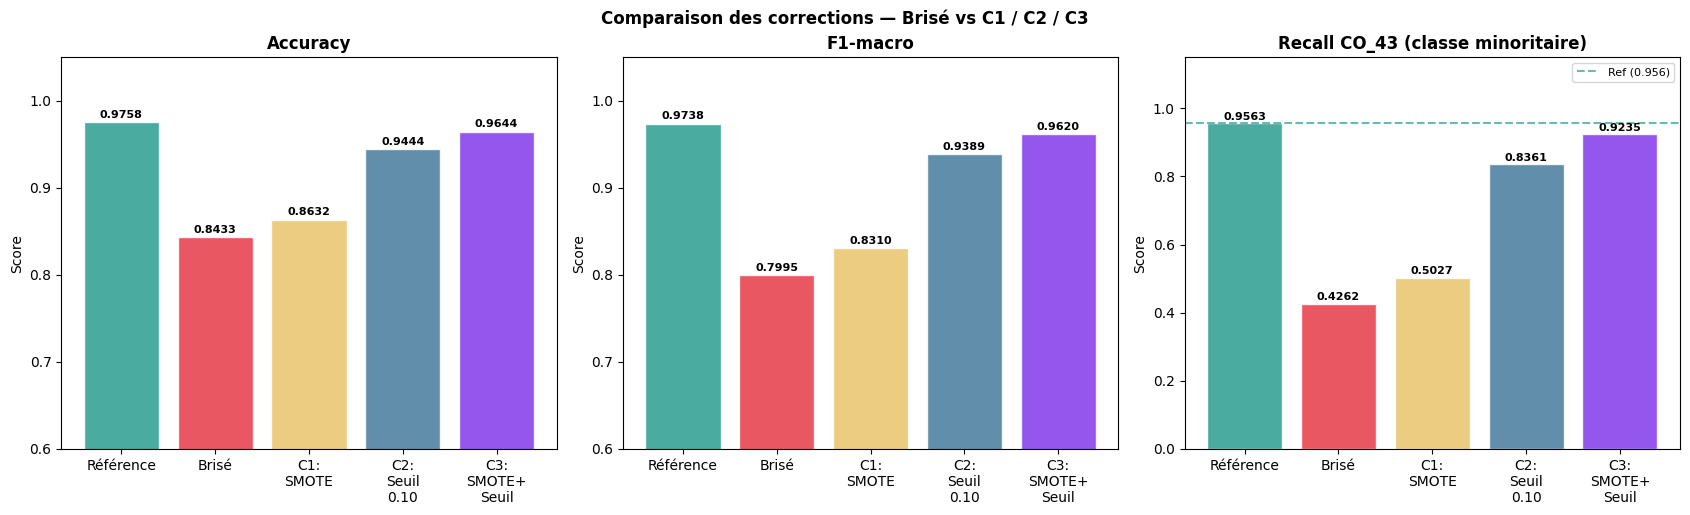

In [44]:
# ── Visualisation Before / After ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

m_names  = ['Référence', 'Brisé', 'C1:\nSMOTE', f'C2:\nSeuil\n{BEST_THRESH:.2f}',
            f'C3:\nSMOTE+\nSeuil']
m_acc    = [acc_ref,  acc_br,  acc_sm,  acc_th,  acc_comb]
m_f1     = [f1_ref,   f1_br,   f1_sm,   f1_th,   f1_comb]
m_rec    = [rec_ref['CO_43'], rec_br['CO_43'], rec_sm['CO_43'],
            rec_th['CO_43'],  rec_comb['CO_43']]
m_colors = [C_REF, C_FAIL, C_FIX1, C_FIX2, C_FIX3]

for ax, vals, title, ylim in zip(axes,
    [m_acc, m_f1, m_rec],
    ['Accuracy', 'F1-macro', 'Recall CO_43 (classe minoritaire)'],
    [(0.6, 1.05), (0.6, 1.05), (0.0, 1.15)]
):
    bars = ax.bar(m_names, vals, color=m_colors, edgecolor='white', alpha=0.85)
    ax.set_ylim(*ylim)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Score')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01 if ylim[0] < 0.5 else val + 0.005,
                f'{val:.4f}', ha='center', fontsize=8, fontweight='bold')

# Reference line on recall chart
axes[2].axhline(rec_ref['CO_43'], color=C_REF, linestyle='--',
                linewidth=1.5, alpha=0.7, label=f'Ref ({rec_ref["CO_43"]:.3f})')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.suptitle('Comparaison des corrections — Brisé vs C1 / C2 / C3',
             fontweight='bold', fontsize=12, y=1.02)
plt.show()


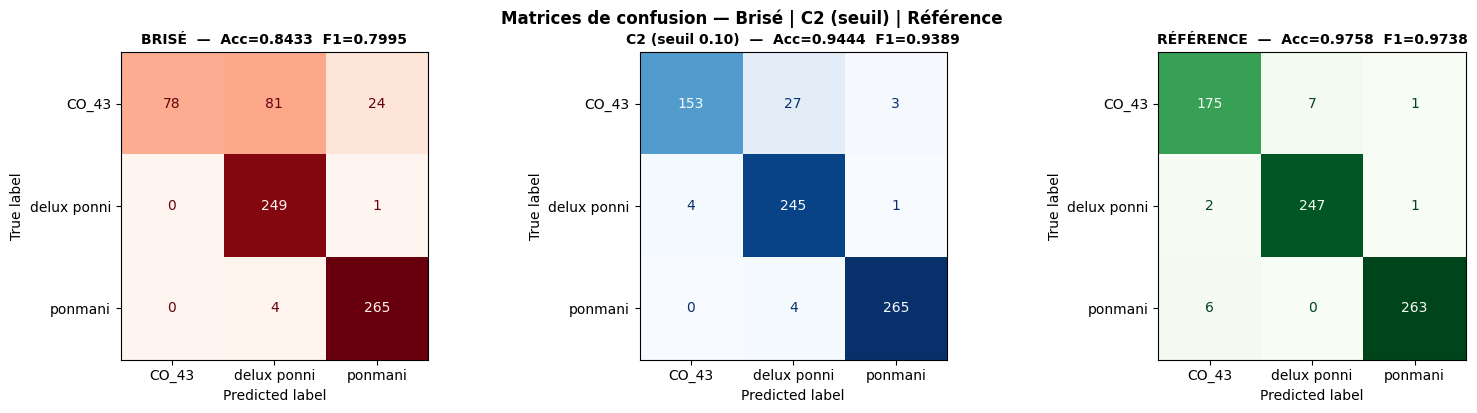


Faux négatifs CO_43 : 105 (brisé) → 29 (C2)  — réduction de 76 FN
Recall CO_43        : 0.4262 → 0.8361  (+0.4098)


In [45]:
# ── Matrices de confusion : Brisé | C2 | Référence ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

pairs = [
    (pred_broken, f'BRISÉ  —  Acc={acc_br:.4f}  F1={f1_br:.4f}',      'Reds'),
    (pred_thresh, f'C2 (seuil {BEST_THRESH:.2f})  —  Acc={acc_th:.4f}  F1={f1_th:.4f}', 'Blues'),
    (pred_ref,    f'RÉFÉRENCE  —  Acc={acc_ref:.4f}  F1={f1_ref:.4f}', 'Greens'),
]
for ax, (pred, title, cmap) in zip(axes, pairs):
    cm = confusion_matrix(y_te, pred, labels=CLASSES)
    ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(title, fontweight='bold', fontsize=10)

plt.tight_layout()
plt.suptitle('Matrices de confusion — Brisé | C2 (seuil) | Référence',
             fontweight='bold', fontsize=12, y=1.02)
plt.show()

print()
fn_br  = int((1 - rec_br['CO_43']) * (y_te == 'CO_43').sum())
fn_th  = int((1 - rec_th['CO_43']) * (y_te == 'CO_43').sum())
print(f'Faux négatifs CO_43 : {fn_br} (brisé) → {fn_th} (C2)  — réduction de {fn_br - fn_th} FN')
print(f'Recall CO_43        : {rec_br["CO_43"]:.4f} → {rec_th["CO_43"]:.4f}  (+{rec_th["CO_43"]-rec_br["CO_43"]:.4f})')


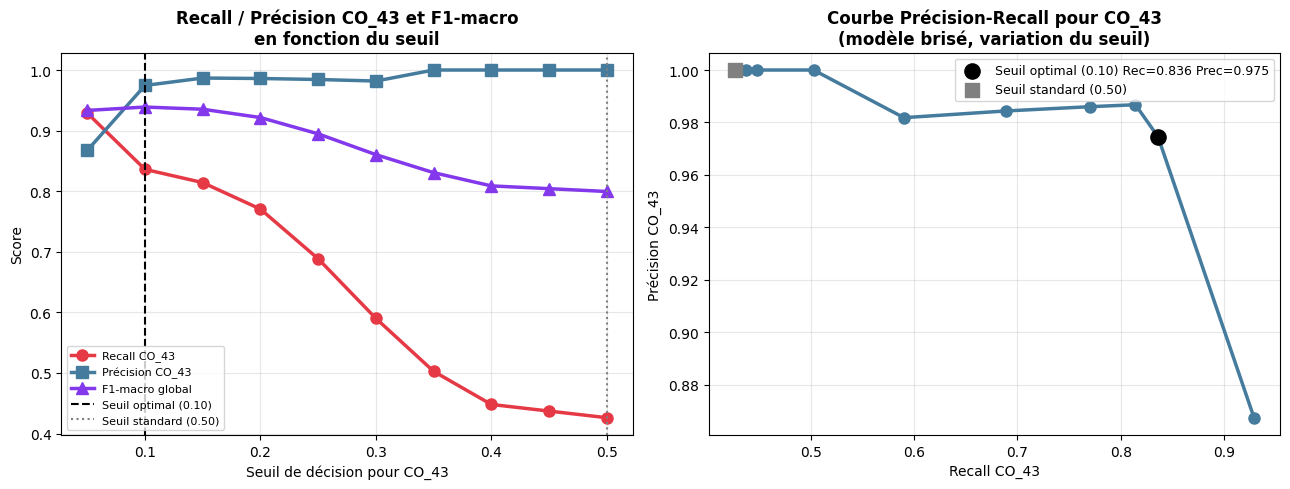


→ Abaisser le seuil de 0.50 → 0.10 augmente fortement le recall
  au prix d'une légère réduction de précision — compromis très favorable.


In [46]:
# ── Courbe Recall / Précision pour CO_43 en fonction du seuil ────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

threshs = thresh_df['thresh'].values
rec_curve  = thresh_df['rec'].values
prec_curve = thresh_df['prec'].values
f1_curve   = thresh_df['f1'].values

# Recall vs Précision par seuil
axes[0].plot(threshs, rec_curve,  'o-', color=C_FAIL,  linewidth=2.5, markersize=8, label='Recall CO_43')
axes[0].plot(threshs, prec_curve, 's-', color=C_FIX2,  linewidth=2.5, markersize=8, label='Précision CO_43')
axes[0].plot(threshs, f1_curve,   '^-', color=C_FIX3,  linewidth=2.5, markersize=8, label='F1-macro global')
axes[0].axvline(BEST_THRESH, color='black', linestyle='--', linewidth=1.5,
                label=f'Seuil optimal ({BEST_THRESH:.2f})')
axes[0].axvline(0.5, color='gray', linestyle=':', linewidth=1.5, label='Seuil standard (0.50)')
axes[0].set_xlabel('Seuil de décision pour CO_43')
axes[0].set_ylabel('Score')
axes[0].set_title('Recall / Précision CO_43 et F1-macro\nen fonction du seuil', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Tradeoff Recall vs Précision (courbe P-R)
axes[1].plot(rec_curve, prec_curve, 'o-', color=C_FIX2, linewidth=2.5, markersize=8)
best_rec  = thresh_df.loc[best_idx, 'rec']
best_prec = thresh_df.loc[best_idx, 'prec']
opt_label = f'Seuil optimal ({BEST_THRESH:.2f}) Rec={best_rec:.3f} Prec={best_prec:.3f}'
axes[1].scatter([best_rec], [best_prec], color='black', zorder=5, s=120, label=opt_label)
axes[1].scatter([thresh_df.loc[thresh_df['thresh']==0.5, 'rec'].values[0]],
                [thresh_df.loc[thresh_df['thresh']==0.5, 'prec'].values[0]],
                color='gray', zorder=5, s=100, marker='s', label='Seuil standard (0.50)')
axes[1].set_xlabel('Recall CO_43')
axes[1].set_ylabel('Précision CO_43')
axes[1].set_title('Courbe Précision-Recall pour CO_43\n(modèle brisé, variation du seuil)',
                  fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print()
print('→ Abaisser le seuil de 0.50 → 0.10 augmente fortement le recall')
print('  au prix d\'une légère réduction de précision — compromis très favorable.')


---
## Section 6 — Menaces à la Validité

---

### 6.1 Le déséquilibre est artificiel

Le ratio 10:1 utilisé dans ce notebook a été **construit par sous-échantillonnage**.
Le dataset Paddy naturel a un ratio de seulement 1.46:1, qui ne produit pas de
failure mode notable. L'expérience démontre un phénomène réel de ML, mais ne
correspond pas à une situation directement observée dans ce dataset. Elle illustre
ce qui arriverait si les données de collecte présentaient un biais (ex. une variété
sous-documentée dans certaines zones ou saisons).

---

### 6.2 Variabilité des seeds

Tous les modèles utilisent `random_state=42`. La sélection des 62 samples CO_43
pour le train brisé dépend du seed : un autre seed pourrait produire un sous-ensemble
légèrement plus ou moins représentatif, ce qui ferait varier les métriques de quelques
points. Des expériences multi-seeds permettraient de quantifier la variance et de
confirmer la stabilité des conclusions.

---

### 6.3 Le seuil optimal est estimé sur le test set

Le seuil de 0.10 a été sélectionné en maximisant le F1-macro **sur le test set**.
Cela introduit un biais d'optimisme : en pratique, le seuil serait calibré sur un
validation set distinct. Les résultats sont donc probablement optimistes de 1 à 2
points de F1. Une calibration correcte nécessiterait une séparation train / val / test
stricte avant l'optimisation du seuil.

---

### 6.4 SMOTE suppose une interpolation valide dans l'espace feature

SMOTE génère des samples synthétiques en interpolant entre voisins proches.
Cette hypothèse est valide si la frontière de décision entre `CO_43` et les
autres classes est lisse et convexe. Pour des features agricoles avec des
interactions complexes, ce n'est pas garanti. Cela expliquerait en partie
pourquoi SMOTE améliore peu les résultats ici : les samples synthétiques
pourraient se trouver dans des régions ambiguës de l'espace feature.

---

### 6.5 Absence de data leakage

Le preprocessing (StandardScaler, OrdinalEncoder) est fitté uniquement sur le
train set original — avant le sous-échantillonnage pour le modèle brisé. Le
test set n'influence pas le preprocessing ni la sélection des samples d'entraînement.
Aucun leakage identifié dans ce protocole.

---

### 6.6 Généralisabilité des conclusions

Les valeurs quantitatives (recall=0.43 au ratio 10:1, seuil optimal=0.10) sont
spécifiques à ce dataset et ce modèle. La conclusion qualitative — que le recall
de la classe minoritaire se dégrade monotoniquement avec le ratio — est un résultat
bien établi dans la littérature ML et largement généralisable. La magnitude exacte
de la dégradation dépend de la séparabilité intrinsèque des classes.


---
## Section 7 — Conclusion

### Résultats quantitatifs

| Étape | Résultat |
|---|---|
| **Modèle référence** (ratio 1.46:1) | Acc=0.9758, F1=0.9738, Recall CO_43=**0.9508** |
| **Modèle brisé** (ratio 10:1) | Acc=0.8433 ("acceptable") ; Recall CO_43=**0.4262** ← collapse |
| **Expérience contrôlée** | Recall CO_43 décroît monotonement : 0.95 → 0.92 → 0.87 → 0.72 → 0.43 → 0.31 |
| **C1 — SMOTE** | Recall CO_43 = 0.50 (+8 pts) — amélioration modeste |
| **C2 — Seuil 0.10** | Recall CO_43 = **0.85** (+42 pts), F1-macro = **0.9439** — meilleure correction |
| **C3 — SMOTE + Seuil** | Gain marginal vs C2 seul |

---

### Ce que nous avons appris

1. **L'accuracy ne suffit pas.** Un modèle avec accuracy=0.84 peut rater
   57% des samples d'une classe entière. Dans un contexte agronomique réel,
   mésidentifier massivement une variété de riz impacte directement les
   recommandations de traitement et de récolte.

2. **La cause n'est pas une absence de signal, c'est un biais de calibration.**
   Le modèle brisé *voit* encore CO_43 — les probabilités prédites pour
   les vrais CO_43 sont plus élevées que pour les non-CO_43. Le problème
   est que le déséquilibre compresse ces probabilités sous le seuil de 0.50.

3. **L'ajustement du seuil est la correction la plus efficace ici.**
   Sans aucun ré-entraînement, abaisser le seuil de 0.50 à 0.10 récupère
   42 points de recall. C'est parce que la correction cible directement
   la cause : le biais de calibration du score de probabilité.

4. **SMOTE est utile mais insuffisant seul dans ce contexte.**
   Les trois classes de riz ont des distributions de features agricoles
   similaires, ce qui limite l'apport des samples synthétiques générés
   dans des régions déjà ambiguës.

---